In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown


In [4]:
# Data path
base_path = Path('C:/Users/User/OneDrive/Desktop/UN')
data_path = Path('C:/Users/alfon/Desktop/UN/Data')

data_files_dict = {'index_1030' : ['index_1030 Gender Development Index.xlsx', '2025_metadata_Gender Development Index 2025.xlsx'],
                   'index_9' : ['index_9 EGDI.xlsx', '20251102_metadata_E-Government Development Index_2024.xlsx', 'raw_EGDI_2024.xlsx'],
                   'index_1032': ['20260710_historical data_index_1032_SDG 2026.xlsx', '20260710_metadata_Sustainable_Development_Index_2026.xlsx', 'raw_SDG_2026.xlsx'],
                   'index_1024' : ['index_1024_FII.xlsx', '', ''],

                    # Somalia indices
                   'index_12' : ['index_12 E-participation Index.xlsx', '', 'raw_EPI_2024.xlsx'],
                   'index_1049' : ['index_1049.xlsx', '', 'raw_IIAG_2024.xlsx'],
                   'index_1037' : ['index_1037.xlsx', '', 'raw_GOVTECH_2022.xlsx'],
                   'index_1022': ['index_1022 Women Peace and security Index.xlsx','','raw_WPS_2025.xlsx'],
                   # Somalia second batch
                   'index_1050': ['index_1050 Global Hunger.xlsx','','raw_GHI.xlsx'],
                   'index_5': ['index_5 ICT Developement Index.xlsx','','raw_ITU_2024.xlsx'],
                   'index_1036': ['20262205_historical data_index_1036_WPF_2026.xlsx','','raw_WPF_2026.xlsx'],

                   # Third
                   'index_1027': ['index_1027 Human Development Index.xlsx','','raw_HDI.xlsx'],
                   'index_1030': ['index_1030 Gender Development Index.xlsx','','raw_GDI_2024.xlsx'],
                   'index_1031': ['index_1031 Planetary adjusted HDI.xlsx','','raw_PPHDI.xlsx'],
                   'index_1035': ['20260303_Historical data _WBL2.0_2026.xlsx','','raw_WBL2.0_2026.xlsx'],
                   # None,
                   'index_1026': ['index_1026 Open data Policies.xlsx','','raw_ODP_2022.xlsx'],
                   'index_1053': ['20260721_historical data_index_1053_BTI2026.xlsx','','raw_BTI_2026.xlsx'],
                   'index_1021': ['index_1021.xlsx','','raw_WBL 1.0.xlsx'],
                   'index_1052': ['20260717_historical data_index_1052_WPJ2026.xlsx','','raw_WJP_2025.xlsx'],
                   'index_1034': ['index_1034.xlsx','','raw_EnviPI_2026.xlsx'],
            
                  }

index_name = 'index_1024'
index_data_files = data_files_dict[index_name]
index_historical_kpi_data_path = Path(data_path) / 'Historical' / index_data_files[0]
# Read raw data
historical_kpi_data_raw = pd.read_excel(index_historical_kpi_data_path)

# Reference Data
escwa_members = ['DZA','BHR','COM','DJI','EGY','IRQ','JOR','KWT','LBN','LBY','MRT',
                 'MAR','OMN','PSE','QAT','SAU','SOM','SDN','SYR','TUN','ARE','YEM']

In [5]:


def process_historical_kpi_data(historical_kpi_data_raw, escwa_members=None, filter_to_escwa=False):
    """
    Reformat and filter raw historical KPI data into a long-format DataFrame.

    Parameters
    ----------
    historical_kpi_data_raw : pd.DataFrame
        Raw historical KPI data (wide format), as loaded from source.
    escwa_members : list-like, optional
        List of ISO codes to filter to, if filter_to_escwa is True.
    filter_to_escwa : bool, default False
        Whether to filter the long-format data to escwa_members.

    Returns
    -------
    historical_kpi_data_long : pd.DataFrame
        Long-format historical KPI data, cleaned and type-cast.
    """
    # Index data minor reformatting and filtering
    historical_kpi_data = historical_kpi_data_raw.copy()
    historical_kpi_data = historical_kpi_data.rename(columns={
        'Unnamed: 0': 'KPI ID',
        'Unnamed: 1': 'Series Name',
        'Unnamed: 2': 'year_historical_automated',
        'year': 'year_historical_automated',
        'Series name': 'Series Name',
        'KeyID': 'KPI ID'
    })
    historical_kpi_data = historical_kpi_data.iloc[1:]

    # Values to change, match simulator values
    replacement_dict = {
        'Mean years of schooling': 'Mean Year of Schooling',
        'Expected years of schooling': 'Expected Year of Schooling'
    }
    historical_kpi_data['Series Name'] = historical_kpi_data['Series Name'].replace(replacement_dict)

    # Long format
    historical_kpi_data_long = historical_kpi_data.melt(
        id_vars=['KPI ID', 'Series Name', 'year_historical_automated'],
        var_name='ISO',
        value_name='data_historical_automated'
    )

    if filter_to_escwa and escwa_members is not None:
        historical_kpi_data_long = historical_kpi_data_long[
            historical_kpi_data_long['ISO'].isin(escwa_members)
        ]

    # Format values for consistency
    historical_kpi_data_long['data_historical_automated'] = pd.to_numeric(
        historical_kpi_data_long['data_historical_automated'], errors='coerce'
    ).astype('Float64')
    historical_kpi_data_long['KPI ID'] = historical_kpi_data_long['KPI ID'].astype(str).str.strip()
    historical_kpi_data_long['year_historical_automated'] = historical_kpi_data_long['year_historical_automated'].astype('Int64')

    return historical_kpi_data_long


historical_kpi_data_long = process_historical_kpi_data(historical_kpi_data_raw, 
                                                       escwa_members=escwa_members, 
                                                       filter_to_escwa=True)

In [6]:
# 1. row count per group, summed, should equal len(df)
group_sizes = historical_kpi_data_long.groupby(["KPI ID", "ISO"], dropna=False).size()
print("sum of group sizes:", group_sizes.sum(), "vs df:", len(historical_kpi_data_long))

# 2. row count actually appended to out_frames inside the function
#    (temporarily add this print inside detect_outliers_by_series, right after
#    out_frames.append(g), or just check before the final .loc reindex)

sum of group sizes: 12915 vs df: 12915


In [270]:

"""
Per-series outlier detection for historical KPI data.
 
Change vs. previous version: trend fitting now compares several candidate
models per series and picks one with a robust BIC, instead of trying a single
logistic curve and falling back to a smoother.
 
Candidates (fewest parameters first)
    median        flat median, 1 parameter -- the "no trend" null model
    linear        Theil-Sen line, 2 parameters
    exponential   Theil-Sen fit in log space, 2 parameters -- for compounding
                  growth (adoption, infrastructure rollout) that hasn't
                  started to level off; y must be > 0 or it's skipped
    quadratic     quadratic with one round of MAD-based trimming, 3 params
    logistic      robust logistic, 4 parameters (unchanged)
 
Selection
    Each candidate is scored with a robust BIC: n*log(s^2) + k*log(n), where
    s is a winsorised residual RMS (see robust_scale). The simplest model
    within `bic_margin`
    of the best score wins. A winning trend model must still reach
    r2_threshold; if it doesn't, a near-tied trend model that does is used,
    and failing that the series falls back to the rolling median as before.
    By default the gate uses a trimmed R^2 (see trimmed_r2), so outliers in
    the series no longer push it onto the smoother by themselves.
 
New / changed columns
    trend_method            adds 'linear' and 'quadratic'; 'median' can now
                            be chosen on merit, not only for short series
    trend_candidate         the model BIC preferred, even if the R^2 gate
                            then rejected it
    bic_median, bic_linear, bic_exponential, bic_quadratic, bic_logistic
                            robust BIC per candidate (NaN if not attempted
                            or the fit failed)
    gate_r2                 the R^2 the gate judged: of the accepted trend
                            model, or of the BIC choice if it was rejected
                            (NaN when the median was chosen; no gate)
    trend_fallback_reason   now explains why the BIC choice was *not* used;
                            NA whenever it was
    trend_r2, logistic_r2   unchanged: ordinary R^2 of the final trend, and
                            of the logistic whenever it fitted
"""
 
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import theilslopes
 
# ---------------------------------------------------------------------------
# 1. Trend-fitting helpers
# ---------------------------------------------------------------------------
def logistic(t, L, k, t0, b):
    return b + L / (1 + np.exp(-k * (t - t0)))
 
 
def modified_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        mad = np.mean(np.abs(x - med))
    if mad == 0:
        return np.zeros_like(x), 0.0
    z = 0.6745 * (x - med) / mad
    return z, mad
 
 
def robust_logistic_fit(t, y):
    """Fit logistic curve; one round of MAD-based downweighting, refit.
    Returns fitted values over t, or None if fit fails."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    L0 = max(y.max() - y.min(), 1e-3)
    b0 = y.min()
    t0_0 = t[np.argmin(np.abs(y - (y.min() + y.max()) / 2))]
    k0 = 4.0 / (t.max() - t.min() + 1e-6)
    p0 = [L0, k0, t0_0, b0]
    bounds = (
        [0, -5, t.min() - 30, -np.inf],
        [L0 * 5 + 1e-6, 5, t.max() + 30, np.inf],
    )
    try:
        popt, _ = curve_fit(logistic, t, y, p0=p0, bounds=bounds, maxfev=20000)
    except Exception:
        return None
 
    fitted = logistic(t, *popt)
    resid = y - fitted
    z, mad = modified_zscore(resid)
    keep = np.abs(z) <= 3.0
    if keep.sum() >= 5 and keep.sum() < len(t):
        try:
            popt2, _ = curve_fit(logistic, t[keep], y[keep], p0=popt,
                                 bounds=bounds, maxfev=20000)
            fitted = logistic(t, *popt2)
        except Exception:
            pass
    return fitted
 
 
def theil_sen_fit(t, y):
    """Theil-Sen line (median of pairwise slopes; tolerates ~29% outliers).
    Returns fitted values over t, or None if the slope is undefined."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    try:
        slope = theilslopes(y, t)[0]
    except Exception:
        return None
    if not np.isfinite(slope):
        return None
    # Intercept as median(y - slope*t). SciPy's default, median(y) -
    # slope*median(t), shifts by about one year's change whenever an outlier
    # crosses the median of a trending series, offsetting the whole line.
    intercept = np.median(y - slope * t)
    return intercept + slope * t
 
 
def exponential_fit(t, y):
    """Theil-Sen line fit to log(y), i.e. a robust a*exp(b*t): the natural
    shape for compounding growth (adoption, infrastructure rollout) that
    hasn't started to level off, without imposing logistic's eventual
    saturation. Same cost as theil_sen_fit -- 2 parameters, same robustness
    to outliers -- so it competes fairly against the linear candidate.
    Returns fitted values over t, or None if any y <= 0 or the fit fails."""
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        return None
    log_fit = theil_sen_fit(np.asarray(t, dtype=float), np.log(y))
    if log_fit is None:
        return None
    return np.exp(log_fit)
 
 
def robust_quadratic_fit(t, y):
    """Quadratic in centred, scaled time; one round of MAD-based trimming,
    refit -- the same scheme as robust_logistic_fit.
    Returns fitted values over t, or None if the fit fails."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    span = t.max() - t.min()
    if span <= 0 or len(np.unique(t)) < 3:
        return None
    tc = (t - t.mean()) / span          # keeps polyfit well conditioned
    try:
        coef = np.polyfit(tc, y, 2)
    except Exception:
        return None
    fitted = np.polyval(coef, tc)
 
    z, _ = modified_zscore(y - fitted)
    keep = np.abs(z) <= 3.0
    if (keep.sum() >= 5 and keep.sum() < len(t)
            and len(np.unique(tc[keep])) >= 3):
        try:
            coef = np.polyfit(tc[keep], y[keep], 2)
            fitted = np.polyval(coef, tc)
        except Exception:
            pass
    return fitted
 
 
TREND_MODELS = {
    "linear": theil_sen_fit,
    "exponential": exponential_fit,
    "quadratic": robust_quadratic_fit,
    "logistic": robust_logistic_fit,
}
N_PARAMS = {"median": 1, "linear": 2, "exponential": 2,
            "quadratic": 3, "logistic": 4}
 
 
def robust_scale(resid, c=3.0, max_capped_frac=0.2):
    """Winsorised RMS of residuals about zero (i.e. about the fitted curve).
 
    Each squared residual is capped at (c * s_mad)^2, where s_mad is the MAD
    scale. Outliers therefore contribute a bounded amount, while ordinary
    points contribute fully -- a pure MAD scale is too noisy to separate
    models reliably (MAD has ~37% Gaussian efficiency). Measured about zero
    rather than the residual median, so an offset fit is penalised.
 
    The cap is scaled to each model's OWN residuals, which creates a failure
    mode: a model whose errors are mostly tiny and a few unboundedly large
    (typical of a compounding extrapolation that drifts further off with
    every step) gets a very tight cap from its many near-zero residuals, and
    every residual beyond it -- whether 3x or 300x the cap -- is charged the
    same fixed amount. That lets such a model hide an arbitrarily bad tail
    behind a small handful of good points, and score as if it were a better
    fit than a model that is moderately, honestly wrong everywhere.
 
    If more than `max_capped_frac` of points would be capped, that is no
    longer "a few contaminating outliers" -- winsorizing would launder a
    systematic misfit, so this falls back to the plain (uncapped) RMS, which
    scales with how wrong the tail actually is."""
    r = np.asarray(resid, dtype=float)
    a = np.abs(r)
    s_mad = 1.4826 * np.median(a)
    if s_mad == 0:
        s_mad = 1.2533 * np.mean(a)
    if s_mad == 0:
        return 0.0
    cap = c * s_mad
    if np.mean(a > cap) > max_capped_frac:
        return float(np.sqrt(np.mean(r ** 2)))
    return float(np.sqrt(np.mean(np.minimum(r ** 2, cap ** 2))))
 
 
def robust_bic(y, fitted, n_params, scale_floor):
    """n*log(s^2) + k*log(n) with a robust residual scale s.
 
    s is floored at `scale_floor`: residual-scale differences below it are
    far under the detectors' noise floor, so they can't change any flag and
    shouldn't decide the model (without the floor, two near-perfect fits
    would be separated by floating-point noise)."""
    n = len(y)
    s = max(robust_scale(y - fitted), scale_floor, 1e-12)
    return n * np.log(s ** 2) + n_params * np.log(n)
 
 
def rank_near_best(bics, margin):
    """Models whose BIC is within `margin` of the best, simplest first."""
    best = min(bics.values())
    return sorted((m for m, b in bics.items() if b <= best + margin),
                  key=N_PARAMS.get)
 
 
def trimmed_r2(y, fitted, z_cut=3.5):
    """R^2 computed without the points this fit itself marks as outliers
    (|modified z of residual| > z_cut). Equals ordinary R^2 when nothing is
    trimmed. Used for the r2_threshold gate so that a series is not pushed
    onto the smoother just because it contains the outliers we are trying
    to find; a genuinely misfitting model still fails, because its
    residuals are wide rather than a few isolated spikes."""
    y = np.asarray(y, dtype=float)
    r = y - np.asarray(fitted, dtype=float)
    z, _ = modified_zscore(r)
    keep = np.abs(z) <= z_cut
    if keep.sum() < 3:
        keep = np.ones_like(keep, dtype=bool)
    yk = y[keep]
    ss_tot = np.sum((yk - yk.mean()) ** 2)
    if ss_tot <= 0:
        return np.nan
    return 1 - np.sum(r[keep] ** 2) / ss_tot
 
 
def diff_outlier_flags(years, values):
    """Flag abrupt jumps/drops in YoY change, plus a monotonicity check
    when the series is overwhelmingly non-decreasing."""
    n = len(values)
    flags = np.zeros(n, dtype=bool)
    if n < 3:
        return flags
    diffs = np.diff(values)
    year_gaps = np.diff(years)
    rate = diffs / year_gaps
 
    z, mad = modified_zscore(rate)
 
    val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
    noise_floor = 0.015 * val_range
    material = np.abs(diffs) > noise_floor
    abrupt = (np.abs(z) > 3.5) & material
 
    frac_nonneg = np.mean(rate >= -1e-9)
    mono_flag = np.zeros(len(rate), dtype=bool)
    if frac_nonneg >= 0.8:
        tol = max(0.02 * val_range, 1e-6)
        mono_flag = rate < -tol
 
    step_flag = abrupt | mono_flag
    flags[1:] = step_flag
    return flags
 
 
# ---------------------------------------------------------------------------
# 2. Detector functions (applied to residuals, per group, below)
# ---------------------------------------------------------------------------
def detect_outliers_iqr_floored(series: pd.Series, multiplier: float = 3.5,
                                value_range: float = None,
                                floor_pct: float = 0.015) -> pd.Series:
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    flagged = (series < lower_bound) | (series > upper_bound)
 
    if value_range is not None:
        noise_floor = floor_pct * value_range
        material = series.abs() > noise_floor
        flagged = flagged & material
 
    return flagged
 
 
def detect_outliers_modified_zscore_floored(series: pd.Series, threshold: float = 3.5,
                                            value_range: float = None,
                                            floor_pct: float = 0.015) -> pd.Series:
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0 or np.isnan(mad):
        return pd.Series(False, index=series.index)
    modified_z_scores = 0.6745 * (series - median) / mad
    flagged = np.abs(modified_z_scores) > threshold
 
    if value_range is not None:
        noise_floor = floor_pct * value_range
        material = series.abs() > noise_floor
        flagged = flagged & material
 
    return flagged
 
 
def detect_outliers_isolation_forest(series: pd.Series,
                                     contamination: float = 0.05) -> pd.Series:
    from sklearn.ensemble import IsolationForest
    s_num = pd.to_numeric(series, errors="coerce")
    notna_pos = np.flatnonzero(~s_num.isna())
    if len(notna_pos) < 30:
        return pd.Series(False, index=series.index)
    X = s_num.iloc[notna_pos].to_numpy().reshape(-1, 1)
    iso = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=200,
        max_samples="auto",
    )
    pred = iso.fit_predict(X)  # 1=inlier, -1=outlier
    mask = pd.Series(False, index=series.index)
    mask.iloc[notna_pos] = (pred == -1)
    return mask
 
 
# ---------------------------------------------------------------------------
# 3. Main entry point
# ---------------------------------------------------------------------------
NUMERIC_NEW_COLS = [
    "fitted_trend", "trend_r2", "logistic_r2", "gate_r2",
    "bic_median", "bic_linear", "bic_exponential", "bic_quadratic",
    "bic_logistic",
    "resid",
    "outlier_iqr", "outlier_zscore", "outlier_isoforest",
    "outlier_diff", "outlier_total",
]
STRING_NEW_COLS = ["trend_method", "trend_candidate", "trend_fallback_reason"]
 
 
def detect_outliers_by_series(
    df: pd.DataFrame,
    group_cols: list = ["KPI ID", "ISO"],
    year_col: str = "year_historical_automated",
    value_col: str = "data_historical_automated",
    iqr_multiplier: float = 3.5,
    zscore_threshold: float = 3.5,
    isoforest_contamination: float = 0.05,
    rolling_window_years: int = 5,
    r2_threshold: float = 0.85,
    noise_floor_pct: float = 0.015,
    min_points_logistic: int = 8,
    min_points_rolling: int = 5,
    min_points_linear: int = 4,
    min_points_quadratic: int = 8,
    min_points_exponential: int = 4,
    trend_candidates: tuple = ("linear", "exponential", "quadratic", "logistic"),
    bic_margin: float = 2.0,
    r2_gate: str = "trimmed",
) -> pd.DataFrame:
    """
    Detect outliers per (group_cols) time series, e.g. per (KPI ID, ISO).
 
    Preserves the original dataframe's shape exactly -- rows with missing
    year/value are kept, they just get NaN/NA in the outlier/trend columns.
 
    Returns a new dataframe with the same rows as `df` plus:
        fitted_trend, trend_r2, logistic_r2, gate_r2,
        bic_median, bic_linear, bic_exponential, bic_quadratic, bic_logistic,
        resid,
        trend_method, trend_candidate, trend_fallback_reason,
        outlier_iqr, outlier_zscore, outlier_isoforest, outlier_diff,
        outlier_total
 
    Trend selection
    ---------------
    1. Fit the flat median plus every model in `trend_candidates` that has
       enough points (min_points_linear / _quadratic / _logistic).
    2. Score each with robust_bic; keep those within `bic_margin` of the
       best. The simplest of these is `trend_candidate`.
    3. If that is 'median', use it: no trend beat the null model.
       Otherwise use the simplest near-tied trend model with
       R^2 >= r2_threshold; if none reaches it, fall back to the rolling
       median (or the flat median when n < min_points_rolling).
 
    `trend_candidates` restricts which trend models compete, e.g.
    ("linear", "logistic") to drop exponential and quadratic. The median
    always competes. Exponential is skipped series-by-series wherever the
    series has a value <= 0, regardless of this setting.
 
    `r2_gate` is 'trimmed' (default; see trimmed_r2) or 'ordinary' (the
    previous version's behaviour, which lets outliers depress R^2 and push
    the series onto the smoother).
 
    trend_method values
    -------------------
    'logistic' | 'quadratic' | 'exponential' | 'linear'
                      parametric fit accepted
    'median'          flat median: chosen on merit (reason NA) or forced
                      (reason 'too_few_points', 'constant_series',
                      'fit_failed', or 'low_r2' with n < min_points_rolling)
    'rolling_median'  centred rolling median over `rolling_window_years`
                      (reason 'low_r2')
 
    trend_fallback_reason values (NA when the selection was used as is)
    -------------------------------------------------------------------
    'too_few_points'   n below every candidate's minimum; only the median
    'constant_series'  zero total variance, R^2 undefined
    'fit_failed'       every attempted trend model failed to fit. A single
                       failure shows as NaN in that model's bic_ column
                       despite n >= its minimum
    'low_r2'           BIC preferred a trend model, but no near-tied trend
                       model reached r2_threshold (gate_r2 shows how close)
 
    Note: trend_r2 is not comparable across methods. For 'rolling_median' it
    scores a smoother against the data it smoothed, so it is high almost by
    construction; for 'median' it is <= 0 by construction. Filter or compare
    within trend_method groups.
    """
    unknown = set(trend_candidates) - set(TREND_MODELS)
    if unknown:
        raise ValueError(f"unknown trend_candidates: {sorted(unknown)}")
    if r2_gate not in ("trimmed", "ordinary"):
        raise ValueError("r2_gate must be 'trimmed' or 'ordinary'")
    min_points = {"linear": min_points_linear,
                  "exponential": min_points_exponential,
                  "quadratic": min_points_quadratic,
                  "logistic": min_points_logistic}
 
    df = df.reset_index(drop=True).copy()
    df["_orig_row_"] = df.index
 
    def rolling_median_by_year(t, y, window_years=rolling_window_years):
        t = np.asarray(t, dtype=float)
        y = np.asarray(y, dtype=float)
        out = np.empty(len(y))
        for i, yr in enumerate(t):
            mask = np.abs(t - yr) <= window_years / 2
            out[i] = np.median(y[mask])
        return out
 
    out_frames = []
    for _keys, g in df.groupby(group_cols, sort=False, dropna=False):
        g = g.sort_values(year_col).copy()
        for c in NUMERIC_NEW_COLS:
            g[c] = np.nan
        for c in STRING_NEW_COLS:
            g[c] = pd.Series(pd.NA, index=g.index, dtype="object")
 
        valid = g[[year_col, value_col]].notna().all(axis=1)
        n = int(valid.sum())
 
        if n == 0:
            out_frames.append(g)
            continue
 
        v_idx = g.index[valid]
        t = pd.to_numeric(g.loc[v_idx, year_col], errors="coerce").to_numpy(dtype=float)
        y = pd.to_numeric(g.loc[v_idx, value_col], errors="coerce").to_numpy(dtype=float)
 
        val_range = max(np.nanmax(y) - np.nanmin(y), 1e-9)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
 
        def r2_of(f):
            return 1 - np.sum((y - f) ** 2) / ss_tot if ss_tot > 0 else np.nan
 
        def gate_r2_of(f):
            return trimmed_r2(y, f) if r2_gate == "trimmed" else r2_of(f)
 
        # --- trend fitting: candidates -> robust BIC -> R^2 gate ------------
        fits = {"median": np.full(n, np.median(y))}
        attempted = False
        if ss_tot > 0:
            for name in trend_candidates:
                if n < min_points[name]:
                    continue
                attempted = True
                cand = TREND_MODELS[name](t, y)
                if cand is not None and np.all(np.isfinite(cand)):
                    fits[name] = cand
 
        scale_floor = 0.1 * noise_floor_pct * val_range
        bics = {m: robust_bic(y, f, N_PARAMS[m], scale_floor)
                for m, f in fits.items()}
        near_best = rank_near_best(bics, bic_margin)      # simplest first
        candidate = near_best[0]
        logistic_r2 = r2_of(fits["logistic"]) if "logistic" in fits else np.nan
 
        reason = None
        if ss_tot <= 0:
            reason = "constant_series"
        elif not attempted and trend_candidates:
            reason = "too_few_points"
        elif attempted and len(fits) == 1:
            reason = "fit_failed"
 
        gate_r2 = np.nan
        if candidate == "median":
            method = "median"
        else:
            gate_scores = {m: gate_r2_of(fits[m]) for m in near_best}
            method = next((m for m in near_best
                           if gate_scores[m] >= r2_threshold), None)
            if method is None:
                gate_r2 = gate_scores[candidate]
                reason = "low_r2"
                method = ("rolling_median" if n >= min_points_rolling
                          else "median")
            else:
                gate_r2 = gate_scores[method]
 
        if method == "rolling_median":
            fitted = rolling_median_by_year(t, y)
        else:
            fitted = fits[method]
        r2 = r2_of(fitted)
 
        # --- residual-based detectors ---------------------------------------
        resid = pd.Series(y - fitted, index=v_idx, dtype="float64")
 
        outlier_iqr = (
            detect_outliers_iqr_floored(resid, multiplier=iqr_multiplier,
                                        value_range=val_range,
                                        floor_pct=noise_floor_pct)
            if n >= 4 else pd.Series(False, index=v_idx)
        )
        outlier_zscore = (
            detect_outliers_modified_zscore_floored(resid, threshold=zscore_threshold,
                                                    value_range=val_range,
                                                    floor_pct=noise_floor_pct)
            if n >= 4 else pd.Series(False, index=v_idx)
        )
        outlier_isoforest = detect_outliers_isolation_forest(
            resid, contamination=isoforest_contamination)
        outlier_isoforest = pd.Series(np.asarray(outlier_isoforest).astype(bool),
                                      index=v_idx)
        outlier_diff = pd.Series(np.asarray(diff_outlier_flags(t, y)).astype(bool),
                                 index=v_idx)
 
        # --- write back -----------------------------------------------------
        g.loc[v_idx, "fitted_trend"] = np.round(fitted, 4)
        g.loc[v_idx, "trend_r2"] = np.round(r2, 4)
        g.loc[v_idx, "logistic_r2"] = np.round(logistic_r2, 4)
        g.loc[v_idx, "gate_r2"] = np.round(gate_r2, 4)
        for m in N_PARAMS:
            g.loc[v_idx, f"bic_{m}"] = np.round(bics.get(m, np.nan), 4)
        g.loc[v_idx, "resid"] = np.round(resid.values, 4)
        g.loc[v_idx, "trend_method"] = method
        g.loc[v_idx, "trend_candidate"] = candidate
        g.loc[v_idx, "trend_fallback_reason"] = reason if reason is not None else pd.NA
        g.loc[v_idx, "outlier_iqr"] = outlier_iqr.astype(int).values
        g.loc[v_idx, "outlier_zscore"] = outlier_zscore.astype(int).values
        g.loc[v_idx, "outlier_isoforest"] = outlier_isoforest.astype(int).values
        g.loc[v_idx, "outlier_diff"] = outlier_diff.astype(int).values
        g.loc[v_idx, "outlier_total"] = (g.loc[v_idx, "outlier_iqr"]
                                         + g.loc[v_idx, "outlier_zscore"]
                                         + g.loc[v_idx, "outlier_isoforest"]
                                         + g.loc[v_idx, "outlier_diff"])
        out_frames.append(g)
 
    result = pd.concat(out_frames)
    result = (result.sort_values("_orig_row_")
                    .drop(columns="_orig_row_")
                    .reset_index(drop=True))
    for c in STRING_NEW_COLS:
        result[c] = result[c].astype("string")
    return result
    
# ---------------------------------------------------------------------------
# 4. Diagnostics
# ---------------------------------------------------------------------------
def trend_method_summary(result: pd.DataFrame,
                         group_cols: list = ["KPI ID", "ISO"]) -> pd.DataFrame:
    """One row per trend_method: how many series used it, and the flag rate
    among the points it produced. Use this to check whether flags are being
    driven by fit method rather than by the data."""
    scored = result[result["trend_method"].notna()]
    per_series = scored.groupby(group_cols, dropna=False).agg(
        trend_method=("trend_method", "first"),
        reason=("trend_fallback_reason", "first"),
        n_points=("resid", "size"),
    )
    counts = per_series.groupby("trend_method", dropna=False).agg(
        n_series=("n_points", "size"),
        median_points=("n_points", "median"),
    )
    rates = scored.groupby("trend_method", dropna=False).agg(
        n_points=("resid", "size"),
        pct_any_flag=("outlier_total", lambda s: 100 * (s > 0).mean()),
        pct_two_plus=("outlier_total", lambda s: 100 * (s >= 2).mean()),
        pct_iqr=("outlier_iqr", lambda s: 100 * s.mean()),
        pct_zscore=("outlier_zscore", lambda s: 100 * s.mean()),
        pct_isoforest=("outlier_isoforest", lambda s: 100 * s.mean()),
        pct_diff=("outlier_diff", lambda s: 100 * s.mean()),
    )
    return counts.join(rates).round(2)


def fallback_reason_summary(result: pd.DataFrame,
                            group_cols: list = ["KPI ID", "ISO"]) -> pd.Series:
    """Count of series by why the logistic fit was not used."""
    scored = result[result["trend_method"].notna()]
    per_series = scored.groupby(group_cols, dropna=False)["trend_fallback_reason"].first()
    return per_series.value_counts(dropna=False)

result = detect_outliers_by_series(historical_kpi_data_long)
assert len(result) == len(historical_kpi_data_long), \
    f"row count mismatch: {len(result)} vs {len(historical_kpi_data_long)}"

result = detect_outliers_by_series(historical_kpi_data_long)
assert len(result) == len(historical_kpi_data_long), \
    f"row count mismatch: {len(result)} vs {len(historical_kpi_data_long)}"

trend_summary = trend_method_summary(result)


In [337]:
trend_summary

,n_series,median_points,n_points,pct_any_flag,pct_two_plus,pct_iqr,pct_zscore,pct_isoforest,pct_diff
trend_method,,,,,,,,,
exponential,49,5.0,499,19.04,6.81,5.61,10.82,1.20,11.02
linear,70,6.0,717,14.92,6.56,6.14,9.48,1.12,8.79
logistic,144,18.0,2664,16.18,5.93,4.69,7.81,0.90,11.34
median,663,2.0,1987,5.49,0.60,0.50,2.72,0.00,3.07
quadratic,84,18.5,1504,12.03,3.72,2.79,5.12,0.40,9.24
rolling_median,90,14.5,1396,16.33,7.88,9.38,9.53,1.00,6.59


In [272]:
#result.to_clipboard()

In [273]:
import matplotlib.pyplot as plt

# build ordered list of (KPI ID, ISO) groups, most anomalous first
group_summary = (
    result.groupby(["KPI ID", "ISO"])["outlier_total"]
    .max()
    .reset_index()
    .dropna(subset=["outlier_total"])
    .sort_values("outlier_total", ascending=False)
)
group_summary = group_summary[group_summary["outlier_total"] > 2].reset_index(drop=True)
groups_list = list(zip(group_summary["KPI ID"], group_summary["ISO"], group_summary["outlier_total"]))


def plot_series_with_outliers(g: pd.DataFrame, title: str = None):
    if len(g) == 0:
        raise ValueError("No rows matched for this group.")
    g = g.sort_values("year_historical_automated")
    outliers = g[g["outlier_total"] >= 1]

    # fitted-trend method used for this group, e.g. "exponential" or "rolling_median"
    trend_method = g["trend_method"].dropna().iloc[0] if g["trend_method"].notna().any() else "n/a"

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(g["year_historical_automated"], g["data_historical_automated"],
            marker="o", markersize=4, linewidth=1.5, color="#2563eb",
            label="Actual value", zorder=2)
    ax.plot(g["year_historical_automated"], g["fitted_trend"],
            linestyle="--", linewidth=1.5, color="#6b7280",
            label=f"Fitted trend ({trend_method})", zorder=1)
    ax.scatter(outliers["year_historical_automated"], outliers["data_historical_automated"],
               s=(60 + outliers["outlier_total"] * 40), color="#dc2626",
               edgecolor="black", linewidth=0.7, zorder=3,
               label="Outlier (outlier_total ≥ 1)")
    for _, row in outliers.iterrows():
        ax.annotate(f"{int(row['outlier_total'])}",
                    (row["year_historical_automated"], row["data_historical_automated"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8, color="#dc2626", fontweight="bold")

    ax.set_title(title or
                 f"{g['KPI ID'].iloc[0]} {g['Series Name'].iloc[0]} — {g['ISO'].iloc[0]}  "
                 f"[trend: {trend_method}]")
    ax.set_xlabel("Year")
    ax.set_ylabel(g["Series Name"].iloc[0])
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

_pos = {"i": -1}   # starts before the first item

def next_series():
    """Re-run this cell (or call next_series() again) to advance."""
    _pos["i"] = (_pos["i"] + 1) % len(groups_list)
    kpi, iso, max_ot = groups_list[_pos["i"]]
    print(f"{_pos['i'] + 1} / {len(groups_list)}  —  KPI {kpi} — {iso}  (max outlier_total={int(max_ot)})")
    g = result[(result["KPI ID"] == kpi) & (result["ISO"] == iso)]
    plot_series_with_outliers(g)

def prev_series():
    _pos["i"] = (_pos["i"] - 1) % len(groups_list)
    kpi, iso, max_ot = groups_list[_pos["i"]]
    print(f"{_pos['i'] + 1} / {len(groups_list)}  —  KPI {kpi} — {iso}  (max outlier_total={int(max_ot)})")
    g = result[(result["KPI ID"] == kpi) & (result["ISO"] == iso)]
    plot_series_with_outliers(g)

#next_series()

63 / 120  —  KPI 1352 — YEM  (max outlier_total=3)


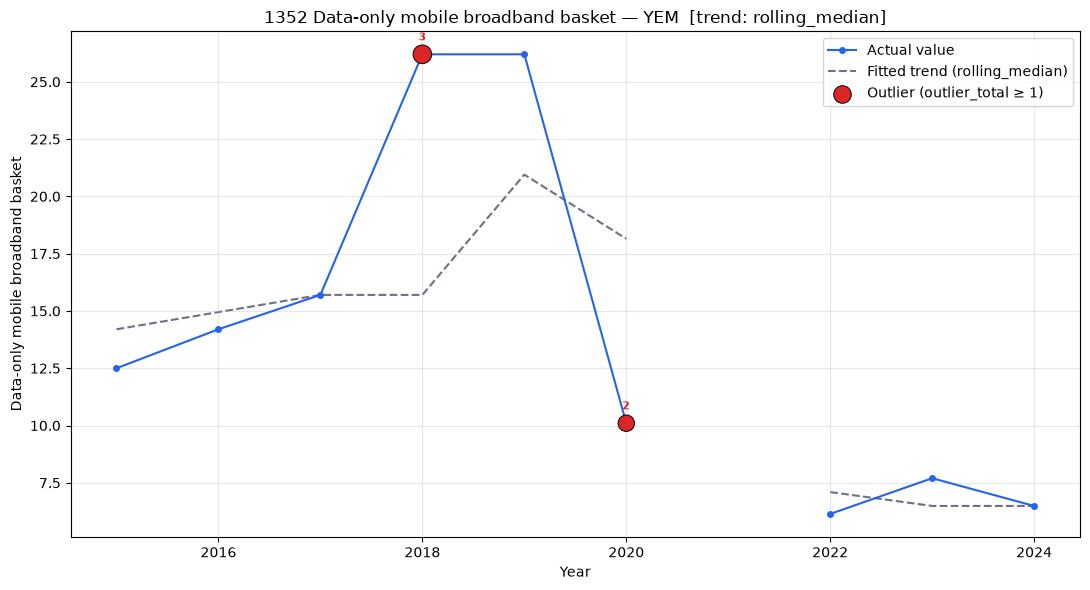

In [336]:
next_series()
#prev_series()

In [43]:
ISO = 'OMN'
KPI = '281'

series =result[(result['KPI ID']==KPI) & (result['ISO']==ISO)].copy()
series = series.sort_values('year_historical_automated')


g = series.sort_values("year_historical_automated").copy()

valid = g[["year_historical_automated", "data_historical_automated"]].notna().all(axis=1)
n = int(valid.sum())

if n == 0:
    out_frames.append(g)


v_idx = g.index[valid]
t = pd.to_numeric(g.loc[v_idx, "year_historical_automated"], errors="coerce").to_numpy(dtype=float)
y = pd.to_numeric(g.loc[v_idx, "data_historical_automated"], errors="coerce").to_numpy(dtype=float)


In [62]:

n = len(y)
flags = np.zeros(n, dtype=bool)

#if n < 3:
#    return flags

diffs = np.diff(y)
year_gaps = np.diff(t)
rate = diffs / year_gaps

z, mad = modified_zscore(rate)

val_range = max(np.nanmax(y) - np.nanmin(y), 1e-9)
noise_floor = 0.015 * val_range
material = np.abs(diffs) > noise_floor
abrupt = (np.abs(z) > 3.5) & material

frac_nonneg = np.mean(rate >= -1e-9)
mono_flag = np.zeros(len(rate), dtype=bool)
if frac_nonneg >= 0.8:
    tol = max(0.02 * val_range, 1e-6)
    mono_flag = rate < -tol

step_flag = abrupt | mono_flag
flags[1:] = step_flag

array([ 0.7809882 ,  1.18639065,  2.36867123,  1.45870153,  0.16515012,
        0.02652864,  1.24206343,  0.02652864,  0.25503364,  0.25503364,
        0.25503364,  0.25503364,  0.25503364,  0.80008882,  0.80007388,
        1.53357955,  0.38455318,  0.5680118 ,  5.39144156,  1.7378426 ,
        1.73785754,  0.56596424,  0.56594929,  0.13731373,  0.13731373,
        0.92416813,  5.24758908,  2.33280152,  0.38432899,  0.12262957,
        1.83966774, 13.89704648])

In [45]:
def diff_outlier_flags(years, values):
    """Flag abrupt jumps/drops in YoY change, plus a monotonicity check
    when the series is overwhelmingly non-decreasing."""
    n = len(values)
    flags = np.zeros(n, dtype=bool)
    if n < 3:
        return flags
    diffs = np.diff(values)
    year_gaps = np.diff(years)
    rate = diffs / year_gaps

    z, mad = modified_zscore(rate)

    val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
    noise_floor = 0.015 * val_range
    material = np.abs(diffs) > noise_floor
    abrupt = (np.abs(z) > 3.5) & material

    frac_nonneg = np.mean(rate >= -1e-9)
    mono_flag = np.zeros(len(rate), dtype=bool)
    if frac_nonneg >= 0.8:
        tol = max(0.02 * val_range, 1e-6)
        mono_flag = rate < -tol

    step_flag = abrupt | mono_flag
    flags[1:] = step_flag
    return flags

array([ 7.8967  ,  8.24739 ,  8.65233 ,  9.21548 ,  9.26646 ,  9.49054 ,
        9.74027 ,  9.82024 , 10.06287 , 10.343178, 10.623486, 10.903794,
       11.184102, 11.46441 , 11.603524, 11.74264 , 11.7836  , 12.08124 ,
       12.40343 , 13.37108 , 13.384706, 13.39833 , 13.568774, 13.73922 ,
       14.003775, 14.26833 , 14.63818 , 14.18214 , 14.11615 , 14.3109  ,
       14.57349 , 14.57349 , 12.96    ])

In [46]:
g

,KPI ID,Series Name,year_historical_automated,ISO,data_historical_automated,fitted_trend,trend_r2,logistic_r2,resid,outlier_iqr,outlier_zscore,outlier_isoforest,outlier_diff,outlier_total,trend_method,trend_fallback_reason
3655,281,Expected Year of Schooling,1990,OMN,7.8967,8.2272,0.9644,0.9644,-0.3305,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3656,281,Expected Year of Schooling,1991,OMN,8.24739,8.4262,0.9644,0.9644,-0.1788,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3657,281,Expected Year of Schooling,1992,OMN,8.65233,8.6365,0.9644,0.9644,0.0159,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3658,281,Expected Year of Schooling,1993,OMN,9.21548,8.8576,0.9644,0.9644,0.3579,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3659,281,Expected Year of Schooling,1994,OMN,9.26646,9.0889,0.9644,0.9644,0.1776,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3660,281,Expected Year of Schooling,1995,OMN,9.49054,9.3296,0.9644,0.9644,0.1610,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3661,281,Expected Year of Schooling,1996,OMN,9.74027,9.5786,0.9644,0.9644,0.1617,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3662,281,Expected Year of Schooling,1997,OMN,9.82024,9.8347,0.9644,0.9644,-0.0145,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3663,281,Expected Year of Schooling,1998,OMN,10.06287,10.0966,0.9644,0.9644,-0.0338,0.0,0.0,0.0,0.0,0.0,logistic,<NA>
3664,281,Expected Year of Schooling,1999,OMN,10.343178,10.3628,0.9644,0.9644,-0.0196,0.0,0.0,0.0,0.0,0.0,logistic,<NA>


In [260]:
ISO = 'KWT'
KPI = '282'

series =result[(result['KPI ID']==KPI) & (result['ISO']==ISO)].copy()
series = series.sort_values('year_historical_automated')

years = pd.to_numeric(series['year_historical_automated'], errors="coerce").to_numpy(dtype=float)
values = pd.to_numeric(series['data_historical_automated'], errors="coerce").to_numpy(dtype=float)

n = len(values)
flags = np.zeros(n, dtype=bool)

diffs = np.diff(values)
year_gaps = np.diff(years)
rate = diffs / year_gaps
z, mad = modified_zscore(rate)

val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
noise_floor = 0.015 * val_range

material = np.abs(diffs) > noise_floor
abrupt = (np.abs(z) > 3.5) & material
frac_nonneg = np.mean(rate >= -1e-9)

C:\Users\User\repos\un\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\User\repos\un\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation fmax which has no identity

In [144]:
val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
noise_floor = 0.015 * val_range
abrupt = (np.abs(z) > 3.5) & material


In [151]:
material = np.abs(diffs) > noise_floor

In [154]:
frac_nonneg

np.float64(0.9)

In [ ]:
t = pd.to_numeric(g.loc[v_idx, year_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(g.loc[v_idx, value_col], errors="coerce").to_numpy(dtype=float)

In [ ]:
282 — KWT

In [121]:
series

,KPI ID,Series Name,year_historical_automated,ISO,data_historical_automated,fitted_trend,resid,outlier_iqr,outlier_zscore,outlier_isoforest,outlier_diff,outlier_total
2072,282,Mean Year of Schooling,2022,KWT,7.3,7.4465,-0.1465,0.0,0.0,0.0,0.0,0.0
2073,282,Mean Year of Schooling,1990,KWT,5.5,5.5796,-0.0796,0.0,0.0,0.0,0.0,0.0
2074,282,Mean Year of Schooling,1991,KWT,5.5,5.6115,-0.1115,0.0,0.0,0.0,0.0,0.0
2075,282,Mean Year of Schooling,1992,KWT,5.6,5.6460,-0.0460,0.0,0.0,0.0,0.0,0.0
2076,282,Mean Year of Schooling,1993,KWT,5.7,5.6834,0.0166,0.0,0.0,0.0,0.0,0.0
2077,282,Mean Year of Schooling,1994,KWT,5.7,5.7238,-0.0238,0.0,0.0,0.0,0.0,0.0
2078,282,Mean Year of Schooling,1995,KWT,5.8,5.7672,0.0328,0.0,0.0,0.0,0.0,0.0
2079,282,Mean Year of Schooling,1996,KWT,5.9,5.8137,0.0863,0.0,0.0,0.0,0.0,0.0
2080,282,Mean Year of Schooling,1997,KWT,6.0,5.8634,0.1366,0.0,0.0,0.0,0.0,0.0
2081,282,Mean Year of Schooling,1998,KWT,6.0,5.9162,0.0838,0.0,0.0,0.0,0.0,0.0


In [ ]:
#============================================================
# C) OUTLIER DETECTION (CONSENSUS)
# ============================================================




def detect_outliers_multiple_methods(
    series: pd.Series,
    consensus_threshold: int = 2,
    iqr_multiplier: float = 3.0,
    zscore_threshold: float = 3.5,
    iso_contamination: float = 0.05,
) -> dict:
    """
    Consensus outlier detection using IQR, modified Z-score, and Isolation Forest.

    Thresholds are now explicit parameters rather than hardcoded, so
    frequency-aware contexts (ctx_d / ctx_m / ctx_q) can pass their own values.
    """
    outliers_iqr = detect_outliers_iqr(series, multiplier=iqr_multiplier)
    outliers_z   = detect_outliers_modified_zscore(series, threshold=zscore_threshold)

    n = series.notna().sum()
    # Cap contamination at a reasonable max; also respect the passed value
    contam = min(iso_contamination, 0.05) if n >= 400 else iso_contamination
    outliers_iso = detect_outliers_isolation_forest(series, contamination=contam)

    counts    = outliers_iqr.astype(int) + outliers_z.astype(int) + outliers_iso.astype(int)
    consensus = counts >= consensus_threshold

    return {
        "outliers":  consensus,
        "iqr":       outliers_iqr,
        "zscore":    outliers_z,
        "isoforest": outliers_iso,
        "counts":    counts,
    }


In [ ]:
# Plan
# - find data that has decent amount of availability 15-25 samples very little missing data
# - compute differences
# - m
# Data
# Year Current, Year Previous, current val, previous val, difference